# Point Surface Drifter: Surface Tracking

This notebook demonstrates the `PointSurfaceDrifter` model — a point particle
at the ocean surface with quadratic drag. The model has two generalized
coordinates (x, y) and at steady state its drift velocity equals the surface
current exactly.

We show:

- How to create a `PointSurfaceDrifter` with default and custom physics.
- Steady-state convergence in a uniform flow.
- That a point drifter only sees the surface (z=0), unlike a drogued drifter
  that samples across depths.

In [1]:
t_end = 600.0

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mechanical_drifters import (
    PointSurfaceDrifter,
    PointSurfacePhysics,
    eval_qdd,
)

## Model creation

`PointSurfaceDrifter()` uses default physics (1 kg mass, 1 kg added mass,
10 kg/m drag). The physics can also be supplied explicitly via `PointSurfacePhysics`.

In [3]:
drifter_default = PointSurfaceDrifter()
print("Default physics:")
print(drifter_default.physics)

Default physics:
PointSurfacePhysics(m=1.0, m_tilde=1.0, k=10.0)


## Steady-state in uniform flow

In a uniform flow `(U, V) = (0.3, 0.0)` the point drifter should converge to
drift at exactly the surface current. We use `PointSurfacePhysics(m=1.0,
m_tilde=1.0, k=10000.0)` — the large drag coefficient makes convergence fast
enough to reach steady state well within `t_end`.

In [4]:
physics_fast = PointSurfacePhysics(m=1.0, m_tilde=1.0, k=10000.0)
drifter = PointSurfaceDrifter(physics_fast)

U_surface = 0.3
V_surface = 0.0

def sample_uv_uniform(z):
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    N = len(z_arr)
    return np.full(N, U_surface), np.full(N, V_surface)

In [5]:
drift_vel, Y_final, max_accel = drifter.steady_state_batch(
    sample_uv_uniform,
    t_span=(0.0, t_end),
)

xd_ss = float(drift_vel[0, 0])
yd_ss = float(drift_vel[0, 1])

print(f"Surface current:       ({U_surface:.3f}, {V_surface:.3f}) m/s")
print(f"Steady-state drift:    ({xd_ss:.6f}, {yd_ss:.6f}) m/s")
print(f"Max residual accel:    {max_accel:.2e} m/s²")

Surface current:       (0.300, 0.000) m/s
Steady-state drift:    (0.299988, 0.000000) m/s
Max residual accel:    6.80e-07 m/s²


In [6]:
assert abs(xd_ss - U_surface) < 1e-4, f"xd_ss too far from U: {xd_ss}"
assert abs(yd_ss - V_surface) < 1e-4, f"yd_ss too far from V: {yd_ss}"
print("Steady-state drift matches surface current  [OK]")

Steady-state drift matches surface current  [OK]


## Sheared flow profile

A point surface drifter only samples the current at z=0. Here we define a
linear shear profile that varies with depth, but the drifter ignores all depths
below the surface — the `sample_uv` callable is called with `z = zeros(N)` in
`_rhs_batch`.

This is the key difference from a drogued drifter, which integrates drag forces
across a range of depths and therefore responds to the depth-averaged current.

In [7]:
def sample_uv_sheared(z):
    """Linear shear: U(z) = 0.5 + 0.1*z (z <= 0 in ocean convention)."""
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    U = 0.5 + 0.1 * z_arr   # positive shear: slower at depth
    V = np.zeros_like(U)
    return U, V

In [8]:
# Surface value (z=0) and a deep value (z=-10 m) for comparison
U_at_surface, _ = sample_uv_sheared(np.array([0.0]))
U_at_depth, _ = sample_uv_sheared(np.array([-10.0]))

print(f"Current at z=0  (surface): {U_at_surface[0]:.3f} m/s")
print(f"Current at z=-10m (depth): {U_at_depth[0]:.3f} m/s")

Current at z=0  (surface): 0.500 m/s
Current at z=-10m (depth): -0.500 m/s


In [9]:
drift_shear, _, max_accel_shear = drifter.steady_state_batch(
    sample_uv_sheared,
    t_span=(0.0, t_end),
)

xd_shear = float(drift_shear[0, 0])
print(f"Steady-state drift (sheared flow): {xd_shear:.6f} m/s")
print(f"Surface current (z=0):             {U_at_surface[0]:.6f} m/s")
print(f"Max residual accel:                {max_accel_shear:.2e} m/s²")

Steady-state drift (sheared flow): 0.500000 m/s
Surface current (z=0):             0.500000 m/s
Max residual accel:                6.69e-10 m/s²


In [10]:
assert abs(xd_shear - U_at_surface[0]) < 1e-4, (
    f"Point drifter should track surface current; got {xd_shear}"
)
print("Point drifter tracks surface value only  [OK]")

Point drifter tracks surface value only  [OK]


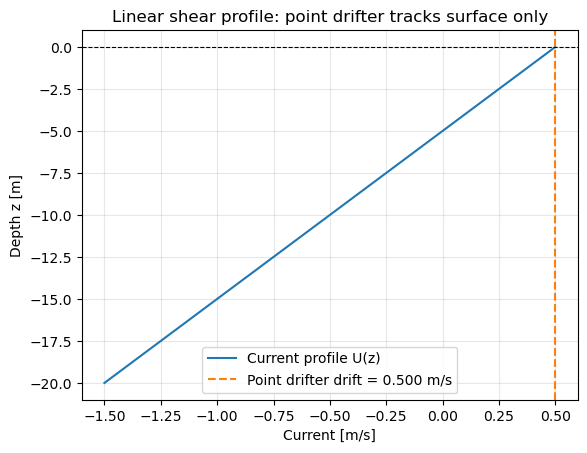

In [11]:
z_profile = np.linspace(0.0, -20.0, 200)
U_profile, _ = sample_uv_sheared(z_profile)

fig, ax = plt.subplots()
ax.plot(U_profile, z_profile, label="Current profile U(z)")
ax.axhline(0.0, color="k", linewidth=0.8, linestyle="--")
ax.axvline(xd_shear, color="C1", linestyle="--", label=f"Point drifter drift = {xd_shear:.3f} m/s")
ax.set_xlabel("Current [m/s]")
ax.set_ylabel("Depth z [m]")
ax.set_title("Linear shear profile: point drifter tracks surface only")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Summary

In [12]:
print("=== PointSurfaceDrifter Summary ===")
print()
print(f"Physics used: {drifter.physics}")
print()
print("Uniform flow test:")
print(f"  Surface current:    ({U_surface:.3f}, {V_surface:.3f}) m/s")
print(f"  Steady-state drift: ({xd_ss:.6f}, {yd_ss:.6f}) m/s")
print(f"  Error (east):       {abs(xd_ss - U_surface):.2e} m/s")
print(f"  Max accel residual: {max_accel:.2e} m/s²")
print()
print("Sheared flow test:")
print(f"  Surface current (z=0):  {U_at_surface[0]:.6f} m/s")
print(f"  Current at z=-10 m:     {U_at_depth[0]:.6f} m/s")
print(f"  Steady-state drift:     {xd_shear:.6f} m/s")
print(f"  Error vs surface:       {abs(xd_shear - U_at_surface[0]):.2e} m/s")
print(f"  Max accel residual:     {max_accel_shear:.2e} m/s²")
print()
print("Conclusion: PointSurfaceDrifter tracks z=0 current in both flows.")

=== PointSurfaceDrifter Summary ===

Physics used: PointSurfacePhysics(m=1.0, m_tilde=1.0, k=10000.0)

Uniform flow test:
  Surface current:    (0.300, 0.000) m/s
  Steady-state drift: (0.299988, 0.000000) m/s
  Error (east):       1.17e-05 m/s
  Max accel residual: 6.80e-07 m/s²

Sheared flow test:
  Surface current (z=0):  0.500000 m/s
  Current at z=-10 m:     -0.500000 m/s
  Steady-state drift:     0.500000 m/s
  Error vs surface:       3.66e-07 m/s
  Max accel residual:     6.69e-10 m/s²

Conclusion: PointSurfaceDrifter tracks z=0 current in both flows.
